In [34]:
import torch
import geospaNN
import numpy as np
import pandas as pd
import random
import matplotlib
import matplotlib.pyplot as plt

path = '../data/Output/'

In [35]:
def f1(X): return 10 * np.sin(2 * np.pi * X)
p = 1;
funXY = f1

sigma = 5
phi = 0.3
Lambda = 0.01
theta = torch.tensor([sigma, phi / np.sqrt(2), Lambda])

n = 1000
nn = 20
b = 10

In [36]:
# Simulate data
rho = np.sqrt(0.7)  # AR(1) coefficient #0.7
sigma_AR = 5  # Standard deviation of noise
x0 = 0  # Initial value

## Simulate white noise
np.random.seed(2024) #2025
epsilon = np.random.normal(0, sigma_AR, n)

## Initialize the process
corerr = np.zeros(n)
corerr[0] = x0

## Generate AR(1) process
for t in range(1, n):
    corerr[t] = rho * corerr[t-1] + epsilon[t]

coord = torch.zeros((n,2))
coord[:,0] = torch.tensor(range(n))/100

In [37]:
torch.manual_seed(2024) 
X, _, _, _, _ = geospaNN.Simulation(n, p, nn, funXY, theta, range=[0, b])
Y = funXY(X) + corerr.reshape((-1,1))
Y = Y.reshape(-1)

# Preprocess data
random.seed(2024)
X, Y, coord, _ = geospaNN.spatial_order(X.float(), Y.float(), coord, method='max-min')
data = geospaNN.make_graph(X, Y, coord, nn)

np.random.seed(0)
data_train, data_val, data_test = geospaNN.split_data(X, Y, coord, neighbor_size=nn,
                                                      test_proportion=0.2)

In [38]:
# Fit NN                                                    
torch.manual_seed(2024)
mlp_nn = torch.nn.Sequential(
    torch.nn.Linear(p, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1),
)
trainer_nn = geospaNN.nn_train(mlp_nn, lr=0.01, min_delta=0.001)
training_log = trainer_nn.train(data_train, data_val, data_test, seed = 2025)
theta0 = geospaNN.theta_update(mlp_nn(data_train.x).squeeze() - data_train.y, 
                               data_train.pos, neighbor_size=20)

INFO: Early stopping
End at epoch39
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[7.1291125e+01 2.1337172e+01 1.0000000e-03]


In [39]:
# Fit NN-GLS
torch.manual_seed(2024)
mlp_nngls = torch.nn.Sequential(
    torch.nn.Linear(p, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1),
)
model = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_nngls, 
                       theta=torch.tensor(theta0))
trainer_nngls = geospaNN.nngls_train(model, lr=0.1, min_delta=0.001)
training_log = trainer_nngls.train(data_train, data_val, data_test, epoch_num= 200, 
                                   Update_init=20, Update_step=10, seed = 2025)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[7.37260087e+01 2.38637914e+01 4.71493254e-02]
to
[7.37260087e+01 2.38637914e+01 4.71493254e-02]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[7.18625688e+01 2.02888062e+01 1.00000000e-03]
to
[7.18625688e+01 2.02888062e+01 1.00000000e-03]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[7.20543883e+01 2.02036115e+01 1.00000000e-03]
to
[7.20543883e+01 2.02036115e+01 1.00000000e-03]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[7.2621403e+01 2.0677732e+01 1.0000000e-03]
to
[7.2621403e+01 2.0677732e+01 1.0000000e-03]
INFO: Early stopping
End at epoch53


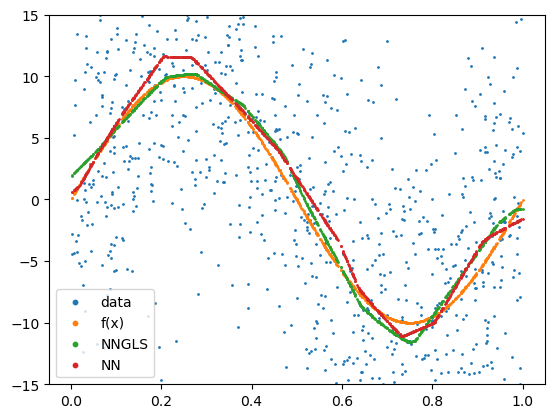

In [40]:
# Estimation and save the figure
estimate = model.estimate(X)
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
plt.scatter(X.detach().numpy(), estimate, s=1, label='NNGLS')
plt.scatter(X.detach().numpy(), mlp_nn(X).detach().numpy(), s=1, label='NN')
lgnd = plt.legend()
plt.ylim([-15, 15])
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'Estimation_AR.png')

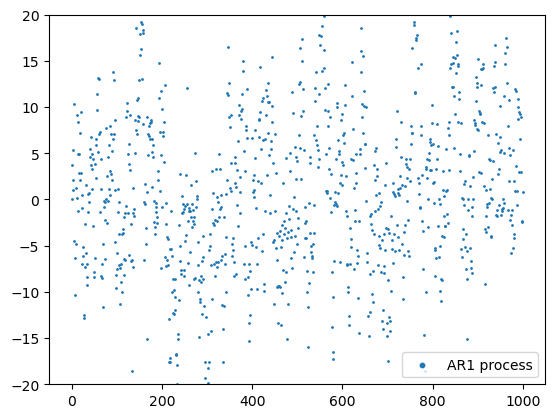

In [41]:
# Plot AR(1) process
plt.clf()
plt.scatter(range(n), corerr, s=1, label='AR1 process')
plt.ylim([-20, 20])
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'AR.png')

In [42]:
# Compute loss
def RMSE(x,y):
    x = x.reshape(-1)
    y = y.reshape(-1)
    n = x.shape[0]
    return(np.sqrt(np.sum(np.square(x-y))/n))

In [43]:
RMSE(estimate.detach().numpy(), funXY(X).reshape(-1).detach().numpy())

np.float32(0.9260114)

In [44]:
RMSE(mlp_nn(X).detach().numpy(), funXY(X).reshape(-1).detach().numpy())

np.float32(1.1337072)